In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


In [2]:
## Load the Dataset

import pandas as pd
df = pd.read_csv("customer_churn_nn.csv")
df.head()


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
## No. of rows and columns

print("\n Shape of Dataset")
df.shape


 Shape of Dataset


(2000, 17)

The target variable in this dataset is churn.
It indicates whether a customer has stopped using the company’s service or has continued using it.
The variable has two possible values:
0 = Customer has not churned / customer continued the service
1 = Customer has churned / customer left the service

In [4]:
## Types of Input features

print("\n Types of data")
df.dtypes


 Types of data


,0
customer_id,object
region,object
plan_type,object
contract_type,object
payment_method,object
tenure_months,int64
monthly_charges_inr,float64
avg_login_days_per_month,int64
support_tickets_last_90_days,int64
payment_delay_days,int64


In [5]:
## Target Variable description

print("\n Target Variable Information")

if 'churn' in df.columns:
    print("Target Variable : churn")
    print(df['churn'].value_counts())
else:
    print("Target column 'churn' not found")



 Target Variable Information
Target Variable : churn
churn
0    1969
1      31
Name: count, dtype: int64


In [6]:
## Missing value check

print("\n Missing value check")
print(df.isnull().sum())


 Missing value check
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [9]:
## Total Missing Values

print("\n Total Missing Values in Dataset :", df.isnull().sum().sum())


 Total Missing Values in Dataset : 0


In [11]:
## Basic statistical summary
print("\n Statistical Summary\n")
print(df.describe())



 Statistical Summary

       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000      

In [8]:
# Distribution of Target variable

print("\nTarget variable distribution:")
print(df['churn'].value_counts())

print("\nTarget variable percentage:")
print(df['churn'].value_counts(normalize=True) * 100)


Target variable distribution:
churn
0    1969
1      31
Name: count, dtype: int64

Target variable percentage:
churn
0    98.45
1     1.55
Name: proportion, dtype: float64


In [12]:
## Task 2: Data Preprocessing

# Display Dataset

print("\n First 5 Rows")
print(df.head())

# STEP 1 : HANDLING MISSING VALUES

print("\n Missing Values Before Handling")
print(df.isnull().sum())


 First 5 Rows
  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3        

In [13]:
## Separate Input Features and Target Variable
X = df.drop(columns=["customer_id", "churn"])

# Target variable
y = df["churn"]

X = input features
y = target variable

In [15]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

# Missing value check
print("\nMissing values before preprocessing:")
print(X.isnull().sum())

# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Display shapes
print("\nOriginal training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Categorical Columns:
Index(['region', 'plan_type', 'contract_type', 'payment_method'], dtype='object')

Numerical Columns:
Index(['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count'],
      dtype='object')

Missing values before preprocessing:
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
dtype: int64

Original training s

In [18]:
## Task 3: Neural Network Model Building

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Number of input features
input_dim = X_train_processed.shape[1]

print("Number of input features:", input_dim)

# Build feed-forward neural network
model = Sequential()

# Input layer + hidden layer
model.add(Dense(16, activation='relu', input_shape=(input_dim,)))

# Second hidden layer
model.add(Dense(8, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model structure
model.summary()

print("\n Neural Network Model Building Completed Successfully")

Number of input features: 28


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609 (2.38 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)


 Neural Network Model Building Completed Successfully


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9859 - loss: 0.0415 - val_accuracy: 0.9875 - val_loss: 0.0392
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9875 - loss: 0.0404 - val_accuracy: 0.9875 - val_loss: 0.0398
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9867 - loss: 0.0397 - val_accuracy: 0.9875 - val_loss: 0.0393
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9875 - loss: 0.0392 - val_accuracy: 0.9875 - val_loss: 0.0406
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9875 - loss: 0.0382 - val_accuracy: 0.9875 - val_loss: 0.0405
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9883 - loss: 0.0377 - val_accuracy: 0.9875 - val_loss: 0.0408
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9883 - loss: 0.0370 - val_accuracy: 0.9875 - val_loss: 0.0397
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9883 - loss: 0.0362 - val_accuracy: 0.9875 - val_los

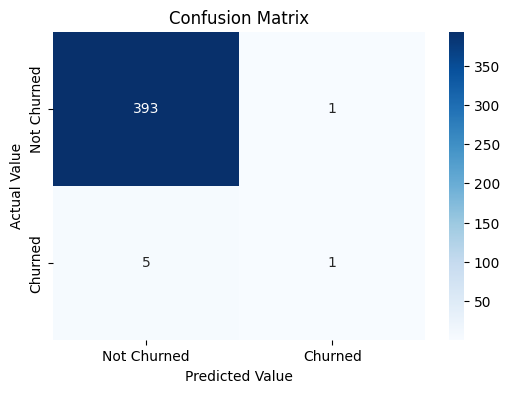

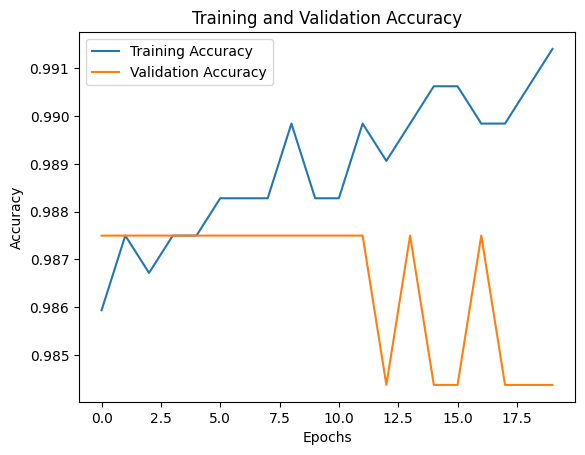

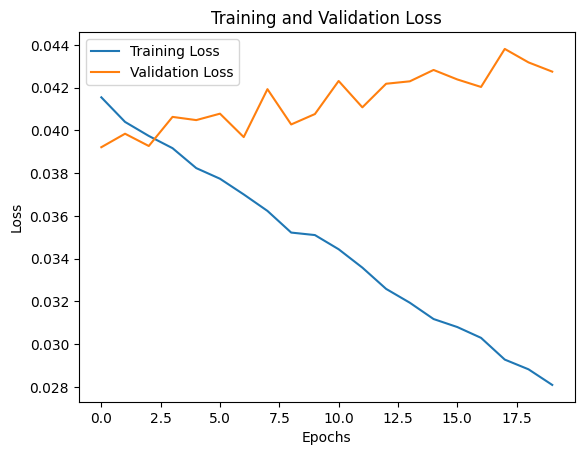

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Train the model
history = model.fit(
    X_train_processed,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# Evaluate on training data
train_loss, train_accuracy = model.evaluate(X_train_processed, y_train)

print("Training Loss:", train_loss)
print("Training Accuracy:", train_accuracy)

# Evaluate on testing data
test_loss, test_accuracy = model.evaluate(X_test_processed, y_test)

print("Testing Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)

# Make predictions
y_pred_prob = model.predict(X_test_processed)

# Convert probabilities to class labels
y_pred = (y_pred_prob > 0.5).astype("int32")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\n Confusion Matrix")
print(cm)


## Plot Confusion Matrix


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")

plt.xticks([0.5, 1.5], ["Not Churned", "Churned"])
plt.yticks([0.5, 1.5], ["Not Churned", "Churned"])

plt.show()

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [24]:
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Function to build model
def build_model(input_dim, hidden_layers, neurons, activation, learning_rate):

    model = Sequential()

    # First hidden layer
    model.add(Dense(neurons[0], activation=activation, input_shape=(input_dim,)))

    # Additional hidden layers
    for i in range(1, hidden_layers):
        model.add(Dense(neurons[i], activation=activation))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Adam optimizer with learning rate
    optimizer = Adam(learning_rate=learning_rate)

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# Experiment settings
experiments = [
    {
        "Experiment": "Experiment 1",
        "Hidden Layers": 1,
        "Neurons": [16],
        "Activation": "relu",
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Epochs": 20
    },
    {
        "Experiment": "Experiment 2",
        "Hidden Layers": 2,
        "Neurons": [32, 16],
        "Activation": "relu",
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Epochs": 30
    },
    {
        "Experiment": "Experiment 3",
        "Hidden Layers": 2,
        "Neurons": [64, 32],
        "Activation": "tanh",
        "Learning Rate": 0.0005,
        "Batch Size": 16,
        "Epochs": 30
    }
]


# List to store results
results = []

# Number of input features
input_dim = X_train_processed.shape[1]


# Run experiments
for exp in experiments:

    print("\nRunning", exp["Experiment"])

    # Build model
    model = build_model(
        input_dim=input_dim,
        hidden_layers=exp["Hidden Layers"],
        neurons=exp["Neurons"],
        activation=exp["Activation"],
        learning_rate=exp["Learning Rate"]
    )

    # Train model
    history = model.fit(
        X_train_processed,
        y_train,
        epochs=exp["Epochs"],
        batch_size=exp["Batch Size"],
        validation_split=0.2,
        verbose=0
    )

    # Evaluate model
    test_loss, test_accuracy = model.evaluate(
        X_test_processed,
        y_test,
        verbose=0
    )

    # Make predictions
    y_pred_prob = model.predict(X_test_processed)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Save result
    results.append({
        "Experiment": exp["Experiment"],
        "Hidden Layers": exp["Hidden Layers"],
        "Neurons": str(exp["Neurons"]),
        "Activation": exp["Activation"],
        "Learning Rate": exp["Learning Rate"],
        "Batch Size": exp["Batch Size"],
        "Epochs": exp["Epochs"],
        "Test Loss": round(test_loss, 4),
        "Test Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4)
    })


# Create comparison table
results_df = pd.DataFrame(results)

# Display table
results_df


Running Experiment 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Running Experiment 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Running Experiment 3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


,Experiment,Hidden Layers,Neurons,Activation,Learning Rate,Batch Size,Epochs,Test Loss,Test Accuracy,Precision,Recall,F1 Score
0,Experiment 1,1,[16],relu,0.0010,32,20,0.0543,0.9850,0.0,0.0000,0.0000
1,Experiment 2,2,"[32, 16]",relu,0.0010,32,30,0.0653,0.9875,1.0,0.1667,0.2857
2,Experiment 3,2,"[64, 32]",tanh,0.0005,16,30,0.0579,0.9875,1.0,0.1667,0.2857


Task 6: Final Reflection
1. Role of Weights and Biases
Weights and biases are the main values that the neural network learns during training.
Weights decide how important each input feature is for making a prediction.
Biases help the model adjust the output, even when the input values are very low or zero.
During training, the model keeps updating the weights and biases to reduce the error between actual and predicted values.
2. Why Activation Function is Required
An activation function helps the neural network learn complex patterns from the data.
Without an activation function, the neural network would behave like a simple linear model.
In this model, ReLU was used in the hidden layers because it helps the model learn faster and handle non-linear relationships.
The sigmoid activation function was used in the output layer because the target variable churn has only two classes: 0 and 1.
3. Effect of Learning Rate
The learning rate controls how fast the model updates its weights during training.
If the learning rate is too high, the model may update weights too aggressively and may not reach the best solution.
If the learning rate is too low, the model learns very slowly and may take many epochs to improve.
So, choosing a suitable learning rate is important for stable and effective training.
4. Underfitting or Overfitting
Underfitting happens when the model is too simple and cannot learn patterns properly from the training data.
Overfitting happens when the model learns the training data too well but performs poorly on testing data.
In this model, if the training accuracy and testing accuracy are close, then the model does not show strong overfitting.
However, because the dataset is highly imbalanced, high accuracy alone may be misleading.
The model may predict most customers as non-churned, which can give high accuracy but poor performance for churned customers.
Therefore, the confusion matrix, recall, and F1-score for class 1 should be checked before making the final conclusion.
Short Final Conclusion
The neural network learned patterns from the customer churn dataset by updating its weights and biases. Activation functions helped the model capture non-linear relationships. The learning rate controlled how quickly the model learned. Based on the results, the model should be evaluated carefully because the target variable was highly imbalanced, and accuracy alone may not fully represent the model’s performance.